# 03 — Random Forest (weekly silver volatility)

Random Forest on the **same three HAR own-history features** used by OLS-HAR. This
is the fair nonlinear comparison to the standard HAR-RV benchmark: same inputs,
different estimator. Cross-asset EXOG spillovers are tested later in the ablation
ladder, rather than baked into the headline model.

Hyperparameters are tuned on the validation split via a small grid, then the model is
re-fit on train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb`
first.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics, vol_diebold_mariano, walk_forward
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_AR1  = ['rv_w_lag1']
FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
print('headline features:', FEATS_HAR)

headline features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / leaf size. Each configuration is fit on the
train split and scored by RMSE on the validation split; the lowest-RMSE configuration
is kept.


In [2]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_rf(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5, None],
                          'min_samples_leaf': [2, 5]})
    best = (np.inf, None)
    for p in grid:
        m = RandomForestRegressor(random_state=SEED, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

rf_best = tune_rf(train_df[FEATS_HAR], y_tr, val_df[FEATS_HAR], y_v)
print('RF best params:', rf_best)


RF best params: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 400}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [3]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

# Single-fit on train+val with the tuned hyperparameters; keeps a canonical `rf`
# model around for §4 feature-importance interpretation.
rf = RandomForestRegressor(random_state=SEED, **rf_best).fit(trval_df[FEATS_HAR], trval_df['target'])
rf_pred_single = rf.predict(test_df[FEATS_HAR])

# Walk-forward RF: refit every 4 weeks on all data up to t-1 (expanding window),
# frozen hyperparameters from §1. Mirrors the returns chapter's `walk_forward()`
# cadence in `notebooks/returns/models/04_random_forest.ipynb` and matches GARCH's
# walk-forward setup in `01_garch`.
def _rf_fit(X, y, params=rf_best):
    return RandomForestRegressor(random_state=SEED, **params).fit(X, y)

rf_pred = walk_forward(frame, test_df.index, FEATS_HAR, fit_fn=_rf_fit, refit_every=4)

results = [vol_evaluate('RF (HAR)', y_test, rf_pred, prev_test)]

# Single-fit RMSE for reference.
print(f'\nSingle-fit RF (HAR) RMSE (for reference): '
      f'{np.sqrt(((y_test - rf_pred_single)**2).mean()):.5f}    '
      f'walk-forward RMSE: {np.sqrt(((y_test - rf_pred)**2).mean()):.5f}')

KeyboardInterrupt: 

## 3. DM vs the Naïve floor — does RF beat $\text{RV}_{t-1}$?

The chapter's central question: is weekly silver volatility predictable beyond last
week's value? The headline RMSE is now in place, but the RF — unlike HAR — buys its
fit using **EXOG cross-asset RVs** on top of the silver lags, so the relevant test is
whether *this* feature set has lower loss than Naïve $\text{RV}_{t-1}$. Diebold-Mariano
(1995) with Newey-West (1987) lag-1 variance via `vol_diebold_mariano`; negative DM =
RF has lower loss.

**QLIKE is the primary loss.** Weekly silver RV is heavy-tailed enough that under
squared-error loss a handful of extreme weeks dominate the differential and inflate the
DM variance, so an RMSE improvement that is real and steady can still fail an MSE-DM
test. The volatility-forecasting literature (Patton 2011) therefore reports forecasts
under **QLIKE**, a proxy-robust ratio loss; squared-error DM is kept underneath only as
a reference. The same comparison is collected across models in `evaluation.ipynb` §4.


In [ ]:
# Diebold-Mariano: RF (HAR) vs the Naive RV_{t-1} floor.
print('QLIKE loss  --  primary test:')
vol_diebold_mariano(y_test, rf_pred, prev_test, 'RF (HAR)', 'Naive', loss='qlike')

print('\nSquared-error loss  --  reference:')
vol_diebold_mariano(y_test, rf_pred, prev_test, 'RF (HAR)', 'Naive', loss='mse');


QLIKE loss  --  primary test:
RF (HAR)                     vs Naive         [qlike]  DM=-2.868  p=0.004  **    -> winner: RF (HAR)

Squared-error loss  --  reference:
RF (HAR)                     vs Naive         [mse  ]  DM=-1.237  p=0.216  (ns)  -> winner: tie


## 4. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [ ]:
period_rf = vol_period_metrics(y_test, rf_pred, prev_test, test_df.index, PERIODS)
period_rf.to_csv('../../../data/processed/period_rf_volatility.csv')
period_rf.round(4)


,n,RMSE,MAE,DCA
Period,,,,
2023 (choppy),52,0.0144,0.0118,0.7115
2024 (bull start),52,0.0149,0.0119,0.8269
2025 (bull run),52,0.0226,0.0161,0.5962
2026 (YTD),18,0.0829,0.0440,0.7222
── Full test ──,174,0.0315,0.0164,0.7126


## 5. Ablations

Same ablation ladder as the HAR-RV ablation in `02_har` §5, with HAR-OLS replaced by
Random Forest throughout. Running the same rungs in two model classes makes the
linear-vs-nonlinear contribution comparable rung-by-rung — any difference between the
matched rung in `02_har` §5 and here is *only* what nonlinearity adds (or loses) on the
same feature set.

| Rung | Tests |
|---|---|
| `RF (AR1)` | trees on last week's RV only — nonlinear AR(1) sanity check |
| `RF (HAR)` | trees on the three HAR features — fair nonlinear comparison to OLS-HAR |
| `RF (HAR+EXOG)` | full cross-asset spillover |
| `RF (HAR+RedditAttention)` | Reddit attention |
| `RF (HAR+RedditSent)` | Reddit tone intensity (\|tone\|) |
| `RF (HAR+Reddit)` | Reddit combined |
| `RF (HAR+Trends)` | Google-search retail attention |
| `RF (HAR+PaidAttention)` | paid-news volume |
| `RF (HAR+PaidSent)` | paid-news tone intensity |
| `RF (HAR+Paid)` | paid-news combined |

Every rung is hyperparameter-tuned independently (`tune_rf` on the sentiment-available
training subsample) and re-fit on train+val of that subsample, so every rung sees the
same observations and the DM comparison is apples-to-apples. **Primary** QLIKE-DM is
each rung vs the bare `RF (HAR)` baseline (mirrors `02_har` §5's "vs `HAR`"); the
**secondary** test pits the combined Reddit rung against `RF (HAR+EXOG)` — mirrors
`02_har` §5's "`HAR+Reddit` vs `HAR+EXOG`".

In [ ]:
FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1',
                #    'reddit_sent_disp_lag1'   # dropped per 00_features §2.5 EDA -- mirrors 02_har §5
                   ]
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT
FEATS_TRENDS    = ['trends_lag1']  # Google-search attention (§5)
FEATS_PAID_ATTN = ['paid_attention_lag1']
FEATS_PAID_INT  = ['paid_sent_abs_lag1']   # paid_sent_disp_lag1 built in 00_features; pending EDA

FEATS_EXOG     = [c for c in frame.columns
                   if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL      = FEATS_HAR + FEATS_EXOG

# True-mirror ablation ladder of 02_har §5: sentiment rungs add to bare HAR (no EXOG).
LADDER = {
    'RF (AR1)':                  FEATS_AR1,
    'RF (HAR)':                  FEATS_HAR,
    'RF (HAR+EXOG)':             FEATS_HAR + FEATS_EXOG,
    'RF (HAR+RedditAttention)':  FEATS_HAR + FEATS_SENT_ATTN,
    'RF (HAR+RedditSent)':       FEATS_HAR + FEATS_SENT_INT,
    'RF (HAR+Reddit)':           FEATS_HAR + FEATS_SENT_ATTN + FEATS_SENT_INT,
    'RF (HAR+Trends)':           FEATS_HAR + FEATS_TRENDS,
    'RF (HAR+PaidAttention)':    FEATS_HAR + FEATS_PAID_ATTN,
    'RF (HAR+PaidSent)':         FEATS_HAR + FEATS_PAID_INT,
    'RF (HAR+Paid)':             FEATS_HAR + FEATS_PAID_ATTN + FEATS_PAID_INT,
}

# Common sample: every rung fitted/scored on weeks where all features exist
all_sent_cols = FEATS_SENT + FEATS_TRENDS + FEATS_PAID_ATTN + FEATS_PAID_INT
abl         = frame.dropna(subset=all_sent_cols)
sent_train  = train_df.dropna(subset=all_sent_cols)
sent_test   = abl[abl['split'] == 'test']
y_st, prev_st = sent_test['target'].values, sent_test['rv_w_lag1'].values
print(f'ablation sample: train+val={(abl["split"]!="test").sum()}  test={len(sent_test)}\n')

# Tune hyperparams once per rung (frozen across the walk-forward refits below)
# and walk forward refitting every 4 weeks.
abl_pred, abl_results = {}, []
for name, feats in LADDER.items():
    best = tune_rf(sent_train[feats], sent_train['target'],
                   val_df[feats],     val_df['target'])
    def _fit(X, y, _b=best):
        return RandomForestRegressor(random_state=SEED, **_b).fit(X, y)
    pred = walk_forward(abl, sent_test.index, feats, fit_fn=_fit, refit_every=4)
    abl_pred[name] = pred
    abl_results.append(vol_evaluate(name, y_st, pred, prev_st))

# Primary QLIKE-DM: each rung vs the bare RF (HAR) baseline -- mirrors 02_har §5
print()
dm = {}
for name in LADDER:
    if name == 'RF (HAR)':
        continue
    dm[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['RF (HAR)'],
                                   name, 'RF (HAR)', loss='qlike')

# Secondary: does the combined Reddit rung beat RF (HAR+EXOG)?
# Mirrors HAR+Reddit vs HAR+EXOG in 02_har §5.
print()
vol_diebold_mariano(y_st, abl_pred['RF (HAR+Reddit)'],
                          abl_pred['RF (HAR+EXOG)'],
                          'RF+Reddit', 'RF+EXOG', loss='qlike')

# Squared-error DM -- reference (mirrors §3; QLIKE is primary)
print('\nSquared-error loss  --  reference:')
dm_mse = {}
for name in LADDER:
    if name == 'RF (HAR)':
        continue
    dm_mse[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['RF (HAR)'],
                                       name, 'RF (HAR)', loss='mse')

print()
vol_diebold_mariano(y_st, abl_pred['RF (HAR+Reddit)'],
                          abl_pred['RF (HAR+EXOG)'],
                          'RF+Reddit', 'RF+EXOG', loss='mse')

abl_df = pd.DataFrame(abl_results)
abl_df['dm_qlike']   = abl_df['model'].map(lambda m: dm[m]['dm']     if m in dm     else np.nan)
abl_df['dm_qlike_p'] = abl_df['model'].map(lambda m: dm[m]['p']      if m in dm     else np.nan)
abl_df['dm_mse']     = abl_df['model'].map(lambda m: dm_mse[m]['dm'] if m in dm_mse else np.nan)
abl_df['dm_mse_p']   = abl_df['model'].map(lambda m: dm_mse[m]['p']  if m in dm_mse else np.nan)
abl_df['winner_dm_qlike'] = abl_df['model'].map(lambda m: dm[m]['winner']     if m in dm     else np.nan)
abl_df['winner_dm_mse']   = abl_df['model'].map(lambda m: dm_mse[m]['winner'] if m in dm_mse else np.nan)

abl_pred_df = pd.DataFrame({'actual': y_abl if 'y_abl' in globals() else y_st,
                            'naive': prev_abl if 'prev_abl' in globals() else prev_st},
                           index=abl_test.index if 'abl_test' in globals() else sent_test.index)
for _name, _pred in abl_pred.items():
    abl_pred_df[_name] = _pred
abl_pred_df.to_csv('../../../data/processed/pred_rf_sentiment_volatility.csv', index_label='Date')
abl_df.to_csv('../../../data/processed/metrics_rf_sentiment_volatility.csv', index=False)
print('\nSaved metrics_rf_sentiment_volatility.csv')
abl_df.round(5)

ablation sample: train+val=402  test=174



RF (AR1)                        RMSE=0.03299  MAE=0.01758  R2=+0.251  DCA=0.661


RF (HAR)                        RMSE=0.03168  MAE=0.01662  R2=+0.309  DCA=0.707


RF (HAR+EXOG)                   RMSE=0.03377  MAE=0.01759  R2=+0.215  DCA=0.684


RF (HAR+RedditAttention)        RMSE=0.03249  MAE=0.01835  R2=+0.273  DCA=0.695


...

RF (HAR+Trends)                 RMSE=0.03147  MAE=0.01703  R2=+0.318  DCA=0.707


RF (HAR+PaidAttention)          RMSE=0.03133  MAE=0.01694  R2=+0.324  DCA=0.684


RF (HAR+PaidSent)               RMSE=0.03130  MAE=0.01648  R2=+0.325  DCA=0.713


RF (HAR+Paid)                   RMSE=0.03102  MAE=0.01663  R2=+0.337  DCA=0.684

RF (AR1)                     vs RF (HAR)      [qlike]  DM=+3.244  p=0.001  **    -> winner: RF (HAR)
RF (HAR+EXOG)                vs RF (HAR)      [qlike]  DM=+1.527  p=0.127  (ns)  -> winner: tie
RF (HAR+RedditAttention)     vs RF (HAR)      [qlike]  DM=+1.974  p=0.048  *     -> winner: RF (HAR)
RF (HAR+RedditSent)          vs RF (HAR)      [qlike]  DM=+0.750  p=0.454  (ns)  -> winner: tie
RF (HAR+Reddit)              vs RF (HAR)      [qlike]  DM=+1.719  p=0.086  (ns)  -> winner: tie
RF (HAR+Trends)              vs RF (HAR)      [qlike]  DM=-0.777  p=0.437  (ns)  -> winner: tie
RF (HAR+PaidAttention)       vs RF (HAR)      [qlike]  DM=+0.233  p=0.816  (ns)  -> winner: tie
RF (HAR+PaidSent)            vs RF (HAR)      [qlike]  DM=-1.538  p=0.124  (ns)  -> winner: tie
RF (HAR+Paid)                vs RF (HAR)      [qlike]  DM=-0.342  p=0.733  (ns)  -> winner: tie

RF+Reddit                    vs RF+EXOG     

,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p,dm_mse,dm_mse_p,winner_dm_qlike,winner_dm_mse
0,RF (AR1),0.03299,0.01758,0.25057,0.66092,3.24355,0.00118,1.84294,0.06534,RF (HAR),tie
1,RF (HAR),0.03168,0.01662,0.30881,0.70690,NaN,NaN,NaN,NaN,NaN,NaN
2,RF (HAR+EXOG),0.03377,0.01759,0.21487,0.68391,1.52665,0.12685,1.63562,0.10192,tie,tie
3,RF (HAR+RedditAttention),0.03249,0.01835,0.27310,0.69540,1.97401,0.04838,0.98115,0.32652,RF (HAR),tie
4,RF (HAR+RedditSent),0.03189,0.01737,0.29965,0.69540,0.74953,0.45354,0.87509,0.38153,tie,tie
5,RF (HAR+Reddit),0.03179,0.01706,0.30414,0.70115,1.71865,0.08568,0.43224,0.66556,tie,tie
6,RF (HAR+Trends),0.03147,0.01703,0.31809,0.70690,-0.77685,0.43725,-0.27222,0.78545,tie,tie
7,RF (HAR+PaidAttention),0.03133,0.01694,0.32393,0.68391,0.23321,0.81560,-0.86656,0.38618,tie,tie
8,RF (HAR+PaidSent),0.03130,0.01648,0.32539,0.71264,-1.53750,0.12417,-1.56281,0.11810,tie,tie
9,RF (HAR+Paid),0.03102,0.01663,0.33724,0.68391,-0.34155,0.73269,-1.37487,0.16917,tie,tie


## 6. Permutation importance — OOS view of the combined sentiment rung

**Permutation importance** (Breiman 2001; sklearn's `permutation_importance`): shuffle each feature in the test set and measure how much the test MSE worsens. A feature with high permutation importance genuinely drives OOS predictions; permutation importance ≈ 0 means the feature contributes nothing out-of-sample even if MDI gives it a non-zero score.

Computed for `RF (HAR+EXOG+Trends+Reddit+Paid)` so all features appear in both panels. The left panel shows **MDI** (in-sample split-counting, biased toward continuous features with many candidate thresholds); the right shows **permutation importance** on the test set. Features where the two diverge are split-on in-sample but don't help OOS.

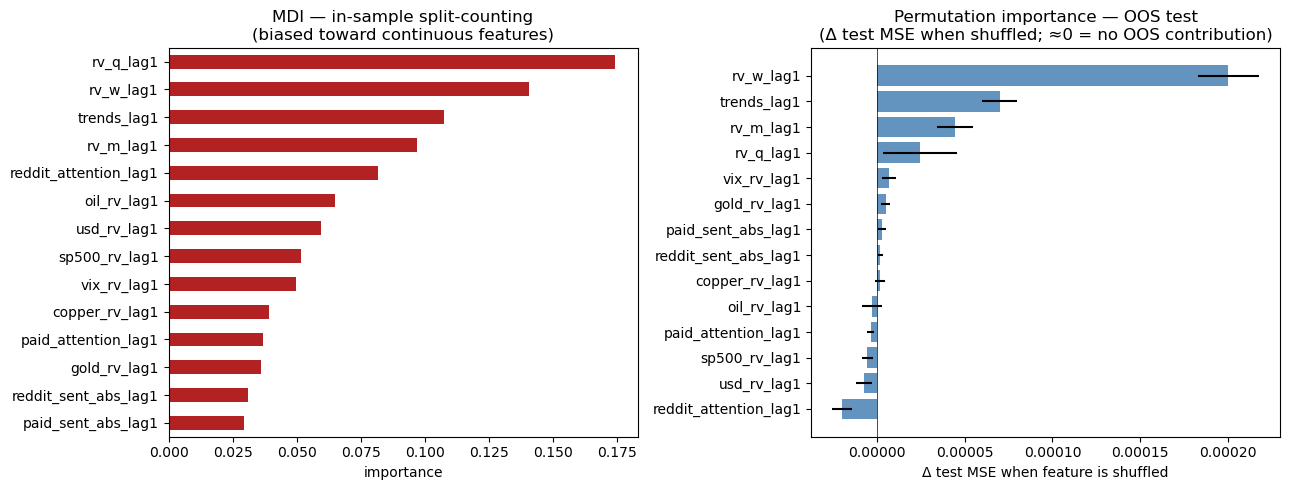

MDI (in-sample) ranking:
rv_q_lag1                0.1745
rv_w_lag1                0.1409
trends_lag1              0.1075
rv_m_lag1                0.0968
reddit_attention_lag1    0.0819
oil_rv_lag1              0.0650
usd_rv_lag1              0.0596
sp500_rv_lag1            0.0515
vix_rv_lag1              0.0496
copper_rv_lag1           0.0394
paid_attention_lag1      0.0370
gold_rv_lag1             0.0361
reddit_sent_abs_lag1     0.0309
paid_sent_abs_lag1       0.0293

Permutation importance (OOS test) ranking:
rv_w_lag1                0.000200
trends_lag1              0.000070
rv_m_lag1                0.000044
rv_q_lag1                0.000024
vix_rv_lag1              0.000007
gold_rv_lag1             0.000005
paid_sent_abs_lag1       0.000003
reddit_sent_abs_lag1     0.000002
copper_rv_lag1           0.000002
oil_rv_lag1             -0.000003
paid_attention_lag1     -0.000004
sp500_rv_lag1           -0.000006
usd_rv_lag1             -0.000008
reddit_attention_lag1   -0.000020


In [ ]:
from sklearn.inspection import permutation_importance

# Re-fit the combined sentiment rung (HAR + EXOG + Reddit + paid-news) canonically on
# sent_trval (single fit on train+val) and compute two importance measures side-by-side
# on the test set:
#   (a) MDI -- in-sample split-counting; biased toward continuous features with
#       many candidate split thresholds (Strobl et al. 2007).
#   (b) Permutation importance (Breiman 2001) -- shuffles each test-set feature
#       and measures the rise in test MSE; a feature with perm-importance ≈ 0
#       contributes nothing to OOS predictions even if MDI gives it a non-zero
#       score.
# The contrast between the two plots is the diagnostic: features where MDI is
# meaningfully positive but permutation importance is ≈ 0 are split-on by the
# trees in-sample but don't help OOS. Sentiment features are expected to fall in
# this category for our small linear effect.
combined_feats = FEATS_HAR + FEATS_EXOG + FEATS_SENT_ATTN + FEATS_SENT_INT + FEATS_TRENDS + FEATS_PAID_ATTN + FEATS_PAID_INT
sent_trval     = abl[abl['split'] != 'test']

combined_best = tune_rf(sent_train[combined_feats], sent_train['target'],
                        val_df[combined_feats],     val_df['target'])
model = RandomForestRegressor(random_state=SEED, **combined_best).fit(
            sent_trval[combined_feats], sent_trval['target'])

mdi  = pd.Series(model.feature_importances_, index=combined_feats)
perm = permutation_importance(model, sent_test[combined_feats], y_st,
                              n_repeats=20, random_state=SEED,
                              scoring='neg_mean_squared_error')
perm_mean = pd.Series(perm.importances_mean, index=combined_feats)
perm_std  = pd.Series(perm.importances_std,  index=combined_feats)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
mdi.sort_values().plot.barh(ax=ax[0], color='firebrick')
ax[0].set_title('MDI — in-sample split-counting\n(biased toward continuous features)')
ax[0].set_xlabel('importance')

ord_perm = perm_mean.sort_values().index
ax[1].barh(ord_perm, perm_mean[ord_perm], xerr=perm_std[ord_perm],
           color='steelblue', alpha=0.85)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].set_title('Permutation importance — OOS test\n(Δ test MSE when shuffled; ≈0 = no OOS contribution)')
ax[1].set_xlabel('Δ test MSE when feature is shuffled')

plt.tight_layout(); plt.show()

print('MDI (in-sample) ranking:')
print(mdi.sort_values(ascending=False).round(4).to_string())
print('\nPermutation importance (OOS test) ranking:')
print(perm_mean.sort_values(ascending=False).round(6).to_string())

## 7. Save outputs

- `metrics_rf_volatility.csv` — Random Forest headline metrics
- `pred_rf_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`
- `metrics_rf_sentiment_volatility.csv` — the §5 sentiment-ablation table (saved above)

In [ ]:
pd.DataFrame(results).to_csv('../../../data/processed/metrics_rf_volatility.csv', index=False)

pred_rf = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'rf': rf_pred}, index=test_df.index)
pred_rf.to_csv('../../../data/processed/pred_rf_volatility.csv', index_label='Date')
print('Saved metrics_rf_volatility.csv + pred_rf_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_rf_volatility.csv + pred_rf_volatility.csv


,model,rmse,mae,r2,dca
0,RF (HAR),0.0315,0.01645,0.31649,0.71264
